In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import time
from pathlib import Path


In [2]:
# load the video
video_path = Path("..") / "data" / "Video_Test_F2787_125743_01_VIDCKPT_sec.mpg"
cap = cv2.VideoCapture(video_path)

In [3]:
show_video = 1

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
window_name = "flight"

cv2.namedWindow(window_name)

# method for setting frame
def on_trackbar_change(trackbar_value):
    cap.set(cv2.CAP_PROP_POS_FRAMES, trackbar_value)
    return 

cv2.createTrackbar("...", window_name, 0, total_frames - 1, on_trackbar_change)

while cap.isOpened():
    if not show_video: break

    current_trackbar_pos = cv2.getTrackbarPos("...", window_name)

    ret, frame = cap.read()
 
    # if frame is read correctly ret is True. ret will be false when video is over
    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break

    # update the trackbar regularly
    current_frame_id = int(cap.get(cv2.CAP_PROP_POS_FRAMES))
    cv2.setTrackbarPos("...", window_name, current_frame_id)

    # gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    cv2.imshow('frame', frame)#, gray)

    # actions to do
    # quit
    if cv2.waitKey(1) == ord('q'):
        break

cv2.destroyAllWindows()

### Mask creation

In [4]:
# define a mask to pick out the apparatus

# TODO load polygons, move and scale them and use them as the mask

cap.set(cv2.CAP_PROP_POS_FRAMES, 0) # set first frame
_, first_frame = cap.read() 
frame_shape = first_frame.shape
mask = np.ones(frame_shape, dtype=np.uint8)

from polygonanalyser import xs_all, ys_all, xs_yb, ys_yb


# https://www.geeksforgeeks.org/dsa/how-to-check-if-a-given-point-lies-inside-a-polygon/
def on_segment(x1, y1, x2, y2, x, y):
    c = (x - x1) * (y2 - y1) - (y - y1) * (x2 - x1)

    if c != 0:
        return False

    return (min(x1, x2) <= x <= max(x1, x2) and
            min(y1, y2) <= y <= max(y1, y2))


def isInside(arr, x, y):
    n = len(arr)
    inside = False

    j = n - 1

    for i in range(n):
        x1, y1 = arr[i]
        x2, y2 = arr[j]

        # Point lies on the current edge
        if on_segment(x1, y1, x2, y2, x, y):
            return True

        # Check whether the horizontal ray from (x, y)
        # intersects the current edge
        intersect = ((y1 > y) != (y2 > y) and
                     x < (x2 - x1) * (y - y1) / (y2 - y1) + x1)

        if intersect:
            inside = not inside

        j = i

    return inside

# fit the polygons to match position of apparatus in frame
def fit_polygon_all_apparatus(xs, ys):
    # shift polygons to upper right corner
    xs -= np.min(xs)
    ys -= np.min(ys)

    # move to proper startting position
    x_move = frame_shape[1]//2 - 10
    y_move = frame_shape[0]//2 + 85
    xs += x_move 
    ys += y_move 
    return xs, ys

def fit_polygon_yellow_black_apparatus(xs, ys):
    # shift polygons to upper right corner
    xs -= np.min(xs)
    ys -= np.min(ys)

    # move to proper startting position
    x_move = frame_shape[1]//2 + 100
    y_move = frame_shape[0]//2 + 85
    xs += x_move 
    ys += y_move 
    return xs, ys

xs_all, ys_all = fit_polygon_all_apparatus(xs_all, ys_all)
xs_yb, ys_yb = fit_polygon_yellow_black_apparatus(xs_yb, ys_yb)

polygon = list(zip(xs_all, ys_all))
polygon = list(zip(xs_yb, ys_yb))

previous_point = polygon[0]
for point in polygon[1:]:
    cv2.line(first_frame, previous_point, point, (255, 0, 0), 5)
    previous_point = point
cv2.line(first_frame, polygon[-1], polygon[0], (255, 0, 0), 5)

mask = np.zeros(frame_shape[:2], dtype=np.uint8)
cv2.fillPoly(
    mask, 
    [np.asarray(polygon, dtype=np.int32)], 
    1
)
        
# The mask is the same for all channelse
# first_frame_masked = np.where(mask == 1, first_frame, 0)
first_frame_masked = first_frame * mask[:, :, None]
cv2.imwrite(Path("..") /"figures" / "image.png", first_frame_masked)




True

### Singular frames 

In [5]:
target_frame = 1
bins = np.arange(0, 256, 10)
# bins = np.arange(0, 1, 0.05)

def normalize_brightness(frame):
    # normalization using LAB frame
    # https://en.wikipedia.org/wiki/CIELAB_color_space
    # L in LAB is "lightness"
    lab_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab_frame)

    # extract the valid l-channel pixels
    valid_l_pixels = l_channel[mask==1].astype(np.float32)

    # normalize brightness channel by mean=255//2, std=50?
    l_mean, l_std = valid_l_pixels.mean(), valid_l_pixels.std()

    normalized_l = (valid_l_pixels - l_mean) / l_std * 50 + 128
    normalized_l = np.clip(normalized_l, 0, 255).astype(np.uint8)
    l_channel[mask==1] = normalized_l

    # merge back
    normalized_LAB = cv2.merge([l_channel, a_channel, b_channel])
    normalized = cv2.cvtColor(normalized_LAB, cv2.COLOR_LAB2BGR)
    return normalized

def extract_im_and_hist(target_frame, mask, savefigs=True):
    cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame) # search up the frame
    ret, frame = cap.read()

    if not ret:
        return 

    # filter the frame and normalize it
    frame_filtered = frame * mask[:, :, None]

    # normalize
    frame_filtered = normalize_brightness(frame_filtered)

    # pick out the valid pixels
    valid_pixels = frame_filtered[mask == 1]

    # get counts (density)
    counts_blue, _ = np.histogram(valid_pixels[:, 0], bins, density=False)
    counts_green, _ = np.histogram(valid_pixels[:, 1], bins, density=False)
    counts_red, _ = np.histogram(valid_pixels[:, 2], bins, density=False)

    if savefigs:
        fig, axs=plt.subplots(3, 1)
        axs[0].plot(bins[:-1], counts_blue)
        axs[1].plot(bins[:-1], counts_green)
        axs[2].plot(bins[:-1], counts_red)
        axs[0].set_title("blue", c="blue")
        axs[1].set_title("green", c="green")
        axs[2].set_title("red", c="red")
        fig.tight_layout()

        fig.savefig(Path("..") / "figures" / "histogram.png")
        plt.close()

        # backconvert frame to integers
        
        cv2.imwrite(Path("..") / "figures" / "image.png", frame_filtered)

    return {
        "counts_blue": counts_blue,
        "counts_green": counts_green,
        "counts_red": counts_red,
    }
target_frame = 10000
target_frame = 4000
# target_frame = 1000
extract_im_and_hist(target_frame, mask, savefigs=1)

{'counts_blue': array([   0,    0,    0,    0,    0, 5651, 7807, 4211, 3197, 2311, 3254,
        9257, 4561, 3969, 3476, 1756,  738,  522,  276,  159,   71,   11,
          13,   16,  170]),
 'counts_green': array([   0,    0,    0,    0,    0, 1503, 9167, 5857, 2964, 2434, 1381,
        1205, 1189, 2268, 7913, 5444, 3427, 2968, 2133,  784,  410,  119,
          61,   15,   18]),
 'counts_red': array([   0,    0,    0,    0,    9, 6538, 8656, 3329, 2126, 1373, 1298,
         874,  805,  769, 1042, 2455, 6558, 3797, 4010, 2547, 2687, 1548,
         665,  138,  354])}

In [6]:
target_frame = 10000 - 1000
for addition in range(0, 10000, 10):
    break    
    extract_im_and_hist(target_frame+addition, mask)
    time.sleep(0.05)

In [7]:
target_frame = 0

for addition in range(0, 5000, 100):
    break
    extract_im_and_hist(target_frame+addition, mask=np.ones(frame_shape))
    time.sleep(0.1)


In [8]:
icing_frames = 10000-1000, 10000-1000 + 10000
noicing_frames = 0, 5000

In [9]:
counts = {
    "icing": {
        "counts_blue": [],
        "counts_green": [],
        "counts_red": []
    },
    "noicing": {
        "counts_blue": [],
        "counts_green": [],
        "counts_red": []
    },
}


In [ ]:

for i in np.arange(icing_frames[0], icing_frames[1], 100):
    histogram_counts = extract_im_and_hist(i, mask, savefigs=True)
    for key in histogram_counts:
        counts["icing"][key].append(histogram_counts[key])
        # time.sleep(0.1)


In [ ]:

for i in np.arange(noicing_frames[0], noicing_frames[1], 100):
    histogram_counts = extract_im_and_hist(i, mask, savefigs=True)
    for key in histogram_counts:
        counts["noicing"][key].append(histogram_counts[key])
        # time.sleep(0.1)

In [ ]:
# convert the lists to numpy arrays
for key in counts:
    for color in counts[key]:
        counts[key][color] = np.array(counts[key][color])

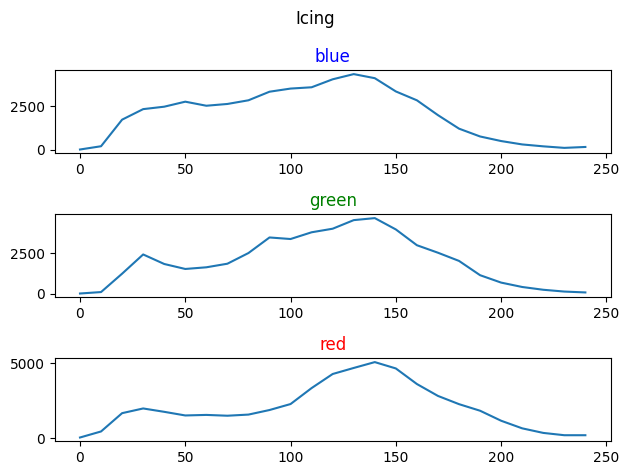

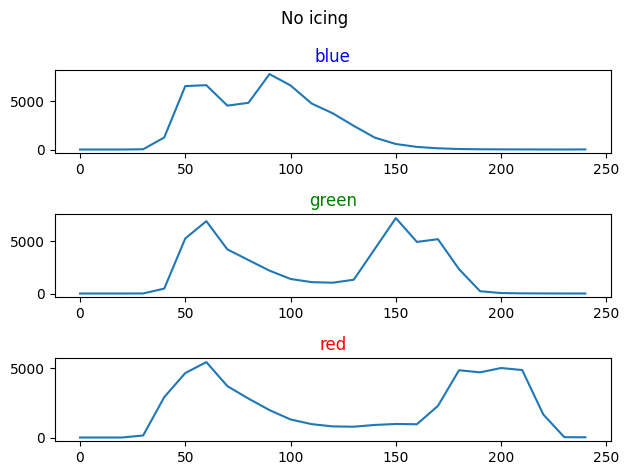

In [ ]:


figicing, axsicing = plt.subplots(3, 1)
for i, key in enumerate(counts["icing"].keys()):
    average_count = counts["icing"][key].mean(axis=0)
    axsicing[i].plot(bins[:-1], average_count)


fignoicing, axsnoicing = plt.subplots(3, 1)
for i, key in enumerate(counts["noicing"].keys()):
    average_count = counts["noicing"][key].mean(axis=0)
    axsnoicing[i].plot(bins[:-1], average_count)
for i, color in enumerate(["blue", "green", "red"]):
    axsicing[i].set_title(color, c=color)
    axsnoicing[i].set_title(color, c=color)

figicing.suptitle("Icing")
fignoicing.suptitle("No icing")
figicing.tight_layout()
fignoicing.tight_layout()